# Career Category Classifier Training

This notebook trains the classifier used in the app to suggest a career direction from CV skills.

Since the dataset does not come with clean category labels, I first discover groups from the skill text itself, then train a supervised model on those discovered labels.

What this notebook covers:
1. Load and clean the jobs dataset
2. Discover category labels from skill patterns (KMeans)
3. Explore class distribution
4. Train/test split
5. Compare Logistic Regression and Random Forest
6. Tune the selected model
7. Evaluate with F1 score, confusion matrix, and error analysis
8. Retrain the job-matching TF-IDF vectorizer
9. Save both artifacts for the app

## 1 — Imports

In [ ]:
import ast
import pickle
import re
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay,
    classification_report,
      f1_score,
    silhouette_score,
)
from sklearn.model_selection import (GridSearchCV,StratifiedKFold,
    cross_val_score,
    train_test_split,
   )
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

ROOT = Path(".")
MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

print("Imports OK")


Imports OK


## 2 — Load and parse the jobs dataset

In [2]:
df = pd.read_csv(ROOT / "data" / "jobs_clean.csv")
print(f"Raw rows: {len(df)}")
df.head()

Raw rows: 785741


,job_title,job_skills,company_name,job_location
0,Senior Clinical Data Engineer / Principal Clin...,[],Boehringer Ingelheim,"Watertown, CT"
1,Data Analyst,"['r', 'python', 'sql', 'nosql', 'power bi', 't...",Hewlett Packard Enterprise,"Guadalajara, Jalisco, Mexico"
2,"Data Engineer/Scientist/Analyst, Mid or Senior...","['python', 'sql', 'c#', 'azure', 'airflow', 'd...",ALPHA Augmented Services,"Berlin, Germany"
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"['python', 'c++', 'java', 'matlab', 'aws', 'te...",Southwest Research Institute,"San Antonio, TX"
4,Data Engineer- Sr Jobs,"['bash', 'python', 'oracle', 'aws', 'ansible',...",Kristina Daniel,"Washington, DC"


In [ ]:
#Convert a stringified Python list of skills into a single lowercase string.
def skills_to_text(value):
    try:
        parsed = ast.literal_eval(value)
        return " ".join(str(s).strip().lower() for s in parsed if str(s).strip())
    except (ValueError, SyntaxError, TypeError):
        return ""


df["skills_text"] = df["job_skills"].fillna("").apply(skills_to_text)
df["title_lower"] = df["job_title"].fillna("").str.lower()

# Drop rows that have no usable skill text
df = df[df["skills_text"].str.strip() != ""].reset_index(drop=True)
print(f"Jobs with skill text: {len(df)}")

Jobs with skill text: 668704


## 3 — Discover labels from the data

Instead of hardcoding category names, I let the dataset form its own groups based on skill text.

Process:
1. Convert skills to TF-IDF vectors
2. Try several values of k and pick the one with the best silhouette score
3. Fit KMeans with that k
4. Name each cluster using its strongest skill terms

Those discovered cluster names become the labels for the supervised classifier.

In [ ]:
# Build TF-IDF features from job skill text
tfidf_discovery = TfidfVectorizer(
    max_features=3000,
    stop_words="english",
    ngram_range=(1, 2),
    sublinear_tf=True,
)
X_all = tfidf_discovery.fit_transform(df["skills_text"])
feature_names = tfidf_discovery.get_feature_names_out()

# Pick k by silhouette score for speed
print("Selecting number of clusters...\n")
sil_scores = {}
for k in range(4, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(X_all)
    score = silhouette_score(X_all, cluster_labels, sample_size=5000, random_state=42)
    sil_scores[k] = score
    print(f"  k={k}: silhouette = {score:.3f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\nChosen k: {best_k}  (silhouette = {sil_scores[best_k]:.3f})")

# Fit final clustering model and assign cluster ids
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["cluster"] = km_final.fit_predict(X_all)

# Name each cluster using the strongest TF-IDF terms in its centroid
def name_cluster_from_centroid(cluster_id):
    centroid = km_final.cluster_centers_[cluster_id]
    top_indices = centroid.argsort()[-4:][::-1]
    top_skills = [feature_names[i] for i in top_indices]
    return " / ".join(s.title() for s in top_skills[:3])

cluster_names = {i: name_cluster_from_centroid(i) for i in range(best_k)}

print("\nDiscovered categories:")
for cluster_id, name in cluster_names.items():
    count = int((df["cluster"] == cluster_id).sum())
    print(f"  Cluster {cluster_id} ({count:>6} jobs): {name}")

# Use discovered names as labels
df["category"] = df["cluster"].map(cluster_names)
labeled = df.copy()

print(f"\nTotal labeled rows: {len(labeled)}")
print()
print(labeled["category"].value_counts())


Searching for best number of clusters...

  k=4: silhouette = 0.034
  k=5: silhouette = 0.039
  k=6: silhouette = 0.042
  k=7: silhouette = 0.051
  k=8: silhouette = 0.055
  k=9: silhouette = 0.060

Best k: 9  (silhouette = 0.060)

Auto-discovered categories (named from top skills per cluster):
  Cluster 0 ( 80479 jobs): Bi / Power / Power Bi
  Cluster 1 ( 27211 jobs): Sql / Sql Python / Python
  Cluster 2 ( 38613 jobs): Sas / Sas Sas / Sas Sql
  Cluster 3 ( 23769 jobs): Python / Python Sql / Sql
  Cluster 4 ( 14059 jobs): Excel / Shell / Wsl
  Cluster 5 ( 11035 jobs): Sql Excel / Excel / Sql
  Cluster 6 (397893 jobs): Python / Sql / Aws
  Cluster 7 ( 47421 jobs): Azure / Databricks / Azure Databricks
  Cluster 8 ( 28224 jobs): Word / Powerpoint / Excel

Total labeled: 668704

category
Python / Sql / Aws                       397893
Bi / Power / Power Bi                     80479
Azure / Databricks / Azure Databricks     47421
Sas / Sas Sas / Sas Sql                   38613
Word / Powe

## 4 — Exploratory Data Analysis

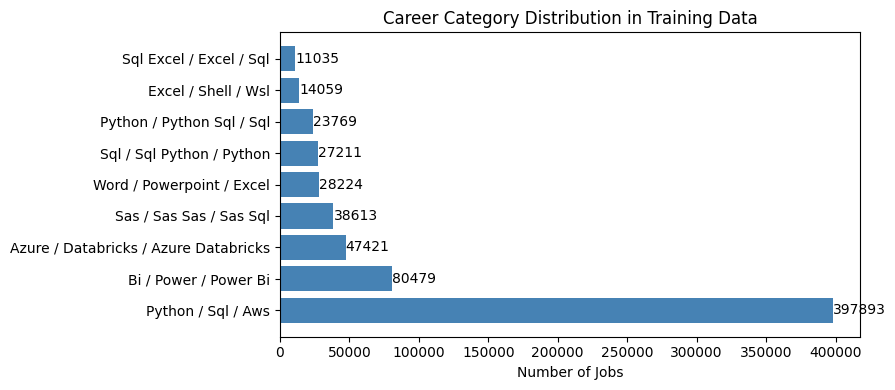

In [22]:
counts = labeled["category"].value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(counts.index, counts.values, color="steelblue")
ax.set_xlabel("Number of Jobs")
ax.set_title("Career Category Distribution in Training Data")
for bar, value in zip(bars, counts.values):
    ax.text(value + 5, bar.get_y() + bar.get_height() / 2, str(value), va="center")
plt.tight_layout()
plt.savefig("category_distribution.png", dpi=120)
plt.show()


In [7]:
# Average number of skills per category
labeled["skill_count"] = labeled["skills_text"].str.split().str.len()
print(labeled.groupby("category")["skill_count"].describe().round(1))

                                          count  mean  std  min  25%  50%  \
category                                                                    
Azure / Databricks / Azure Databricks   47421.0   5.4  2.9  1.0  3.0  5.0   
Bi / Power / Power Bi                   80479.0   5.9  2.8  1.0  4.0  6.0   
Excel / Shell / Wsl                     14059.0   1.1  0.2  1.0  1.0  1.0   
Python / Python Sql / Sql               23769.0   1.8  0.8  1.0  1.0  2.0   
Python / Sql / Aws                     397893.0   6.3  4.3  1.0  3.0  5.0   
Sas / Sas Sas / Sas Sql                 38613.0   7.3  3.3  2.0  5.0  7.0   
Sql / Sql Python / Python               27211.0   2.1  1.1  1.0  1.0  2.0   
Sql Excel / Excel / Sql                 11035.0   3.1  1.1  2.0  2.0  3.0   
Word / Powerpoint / Excel               28224.0   4.9  2.9  1.0  3.0  4.0   

                                       75%   max  
category                                          
Azure / Databricks / Azure Databricks  7.0  22.0  

## 5 — Train / test split

In [8]:
X = labeled["skills_text"]
y = labeled["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")
print()
print("Test class distribution:")
print(y_test.value_counts())

Train: 534963  |  Test: 133741

Test class distribution:
category
Python / Sql / Aws                       79579
Bi / Power / Power Bi                    16096
Azure / Databricks / Azure Databricks     9484
Sas / Sas Sas / Sas Sql                   7722
Word / Powerpoint / Excel                 5645
Sql / Sql Python / Python                 5442
Python / Python Sql / Sql                 4754
Excel / Shell / Wsl                       2812
Sql Excel / Excel / Sql                   2207
Name: count, dtype: int64


## 6 — Compare baseline models

I run 5-fold stratified cross-validation on the training set to compare Logistic Regression and Random Forest under the same TF-IDF settings.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Shared TF-IDF settings for a fair comparison
tfidf_base = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2),
    sublinear_tf=True,
)

lr_pipeline = Pipeline([
    ("tfidf", tfidf_base),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])

rf_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        stop_words="english",
        ngram_range=(1, 2),
        sublinear_tf=True,
    )),
    ("clf", RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1)),
])

results = {}
for name, pipe in [("Logistic Regression", lr_pipeline), ("Random Forest", rf_pipeline)]:
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_macro")
    results[name] = scores
    print(f"{name}: CV F1 macro = {scores.mean():.3f} ± {scores.std():.3f}")

Logistic Regression: CV F1 macro = 0.984 ± 0.000
Random Forest: CV F1 macro = 0.997 ± 0.000


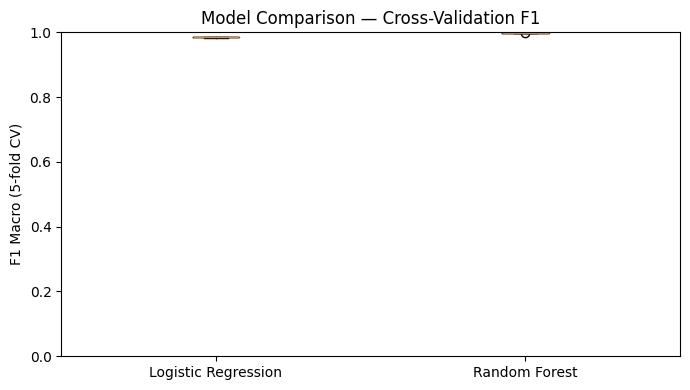

In [ ]:
# Visualize the cross-validation scores
fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(results.values(), tick_labels=results.keys())
ax.set_ylabel("F1 Macro (5-fold CV)")
ax.set_title("Model Comparison — Cross-Validation F1")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120)
plt.show()

## 7 — Tune Logistic Regression

Even though Random Forest scored slightly higher, Logistic Regression is lighter and easier to ship in this app pipeline, so I tune it over C, max_features, and min_df.

In [ ]:
param_grid = {
    "tfidf__max_features": [3000, 5000, 8000],
    "tfidf__min_df": [1, 2],
    "clf__C": [0.1, 1.0, 5.0, 10.0],
}

grid_search = GridSearchCV(
    lr_pipeline,
     param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
     verbose=1,
  )
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV F1 (macro): {grid_search.best_score_:.3f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'clf__C': 10.0, 'tfidf__max_features': 5000, 'tfidf__min_df': 2}
Best CV F1 (macro): 0.990


## 8 — Evaluation on the held-out test set

In [12]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))
print(f"Overall macro F1 : {f1_score(y_test, y_pred, average='macro'):.3f}")
print(f"Overall weighted F1: {f1_score(y_test, y_pred, average='weighted'):.3f}")

                                       precision    recall  f1-score   support

Azure / Databricks / Azure Databricks       0.95      1.00      0.97      9484
                Bi / Power / Power Bi       0.98      1.00      0.99     16096
                  Excel / Shell / Wsl       1.00      1.00      1.00      2812
            Python / Python Sql / Sql       1.00      1.00      1.00      4754
                   Python / Sql / Aws       1.00      0.99      0.99     79579
              Sas / Sas Sas / Sas Sql       0.99      1.00      0.99      7722
            Sql / Sql Python / Python       1.00      1.00      1.00      5442
              Sql Excel / Excel / Sql       0.98      1.00      0.99      2207
            Word / Powerpoint / Excel       0.97      1.00      0.98      5645

                             accuracy                           0.99    133741
                            macro avg       0.98      1.00      0.99    133741
                         weighted avg       0.99  

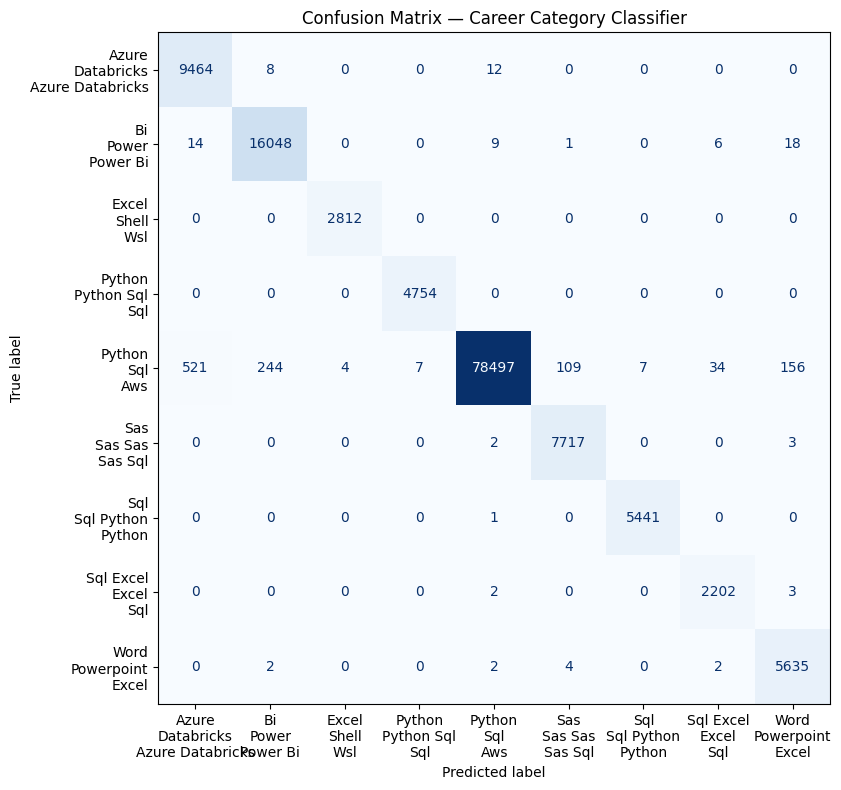

In [24]:
labels = sorted(y.unique())
plot_labels = [label.replace(" / ", "\n") for label in labels]

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=labels,
    display_labels=plot_labels,
    ax=ax,
    colorbar=False,
    cmap="Blues",
)
ax.set_title("Confusion Matrix — Career Category Classifier")
plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120)
plt.show()

## 9 — Error analysis

This section checks where the model still confuses categories so we can see whether mistakes come from overlapping skills or weakly separated clusters.

In [14]:
errors = pd.DataFrame({
    "job_title": labeled.loc[X_test.index, "job_title"].values,
    "skills_text": X_test.values,
    "actual": y_test.values,
    "predicted": y_pred,
})
errors = errors[errors["actual"] != errors["predicted"]].reset_index(drop=True)

print(f"Total errors: {len(errors)} / {len(y_test)} test samples ({100*len(errors)/len(y_test):.1f}%)")
print()
print("Most common confusion pairs:")
confusion_pairs = errors.groupby(["actual", "predicted"]).size().sort_values(ascending=False)
print(confusion_pairs.head(10))

Total errors: 1171 / 133741 test samples (0.9%)

Most common confusion pairs:
actual                                 predicted                            
Python / Sql / Aws                     Azure / Databricks / Azure Databricks    521
                                       Bi / Power / Power Bi                    244
                                       Word / Powerpoint / Excel                156
                                       Sas / Sas Sas / Sas Sql                  109
                                       Sql Excel / Excel / Sql                   34
Bi / Power / Power Bi                  Word / Powerpoint / Excel                 18
                                       Azure / Databricks / Azure Databricks     14
Azure / Databricks / Azure Databricks  Python / Sql / Aws                        12
Bi / Power / Power Bi                  Python / Sql / Aws                         9
Azure / Databricks / Azure Databricks  Bi / Power / Power Bi                      8
dtype

In [15]:
# Sample 10 error rows to understand what's going wrong
pd.set_option("display.max_colwidth", 80)
errors[["job_title", "actual", "predicted"]].head(10)

,job_title,actual,predicted
0,Data Analyst,Python / Sql / Aws,Azure / Databricks / Azure Databricks
1,Data Scientist- Remote,Python / Sql / Aws,Sas / Sas Sas / Sas Sql
2,Data Engineer Fraud Monitoring,Python / Sql / Aws,Azure / Databricks / Azure Databricks
3,Cloud Data Engineer - Healthcare,Python / Sql / Aws,Bi / Power / Power Bi
4,Data Analytics Traineeship,Python / Sql / Aws,Bi / Power / Power Bi
5,Data engineer,Python / Sql / Aws,Azure / Databricks / Azure Databricks
6,Data Engineer,Azure / Databricks / Azure Databricks,Python / Sql / Aws
7,Azure DataOps Engineer,Python / Sql / Aws,Azure / Databricks / Azure Databricks
8,Experienced Cleared Data Scientist,Python / Sql / Aws,Bi / Power / Power Bi
9,Associate Data Analyst,Python / Sql / Aws,Word / Powerpoint / Excel


## 10 — Retrain the job-matching vectorizer

The app also uses a separate TF-IDF vectorizer for job ranking by cosine similarity.
I retrain that vectorizer here on the full dataset so ranking quality stays aligned with the new training pass.

In [16]:
all_job_texts = (
    df["job_title"].fillna("").astype(str) + " " + df["skills_text"]
)

job_vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2),
    sublinear_tf=True,   # log(1 + tf) — reduces the dominance of very frequent terms
)
job_vectorizer.fit(all_job_texts)

print(f"Vocabulary size: {len(job_vectorizer.vocabulary_)}")

Vocabulary size: 5000


## 11 — Save model artifacts

In [17]:
with open(MODELS_DIR / "career_classifier.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open(MODELS_DIR / "vectorizer.pkl", "wb") as f:
    pickle.dump(job_vectorizer, f)

print("Saved: models/career_classifier.pkl")
print("Saved: models/vectorizer.pkl")

Saved: models/career_classifier.pkl
Saved: models/vectorizer.pkl


## 12 — Practical sanity check

Run a few realistic CV-style skill snippets and inspect the top predicted category with confidence.
For ambiguous profiles, also show the second-best category to understand overlap.

In [21]:
with open(MODELS_DIR / "career_classifier.pkl", "rb") as f:
    loaded_classifier = pickle.load(f)

examples = [
    {
        "profile": "Cloud data engineer",
        "skills": "python sql aws terraform airflow spark databricks",
    },
    {
        "profile": "BI reporting analyst",
        "skills": "power bi tableau sql excel dashboard reporting",
    },
    {
        "profile": "Research/statistics role",
        "skills": "sas r statistical analysis clinical data",
    },
    {
        "profile": "General office/data support",
        "skills": "excel word powerpoint documentation scheduling",
    },
    {
        "profile": "Mixed data profile",
        "skills": "python sql pandas visualization stakeholder reporting",
    },
]

print("Sanity check on sample profiles")
print("-" * 80)

for row in examples:
    text = row["skills"]
    pred = loaded_classifier.predict([text])[0]

    if hasattr(loaded_classifier, "predict_proba"):
        probs = loaded_classifier.predict_proba([text])[0]
        classes = loaded_classifier.classes_
        top2_idx = np.argsort(probs)[-2:][::-1]
        top1 = f"{classes[top2_idx[0]]} ({probs[top2_idx[0]]:.2%})"
        top2 = f"{classes[top2_idx[1]]} ({probs[top2_idx[1]]:.2%})"
    else:
        top1 = pred
        top2 = "n/a"

    print(f"Profile : {row['profile']}")
    print(f"Skills  : {text}")
    print(f"Top-1   : {top1}")
    print(f"Top-2   : {top2}")
    print("-")


Sanity check on sample profiles
--------------------------------------------------------------------------------
Profile : Cloud data engineer
Skills  : python sql aws terraform airflow spark databricks
Top-1   : Python / Sql / Aws (99.98%)
Top-2   : Azure / Databricks / Azure Databricks (0.02%)
-
Profile : BI reporting analyst
Skills  : power bi tableau sql excel dashboard reporting
Top-1   : Bi / Power / Power Bi (99.98%)
Top-2   : Sql Excel / Excel / Sql (0.02%)
-
Profile : Research/statistics role
Skills  : sas r statistical analysis clinical data
Top-1   : Sas / Sas Sas / Sas Sql (100.00%)
Top-2   : Python / Sql / Aws (0.00%)
-
Profile : General office/data support
Skills  : excel word powerpoint documentation scheduling
Top-1   : Word / Powerpoint / Excel (100.00%)
Top-2   : Python / Sql / Aws (0.00%)
-
Profile : Mixed data profile
Skills  : python sql pandas visualization stakeholder reporting
Top-1   : Python / Sql / Aws (99.99%)
Top-2   : Python / Python Sql / Sql (0.01%)
-
